# Data download

In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

c:\Study\Programing\deeplearning\Dropout\.venv\Lib\site-packages\cupy\_environment.py:284: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


# Show images

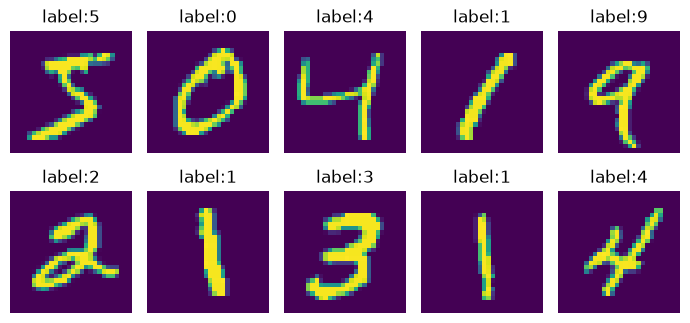

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(7, 3.5))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.imshow(X[i, :].reshape(28, 28))
    ax.set_title(f'label:{y[i]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Data preprocessing

In [8]:
X = (cp.asarray(X) / 255).T
y = cp.asarray(y, dtype=int)

y_oh = cp.zeros((10, y.shape[0]))
for i in range(len(y)):
    y_oh[y[i], i] = 1

random_index = cp.random.permutation(X.shape[1])
X = X[:, random_index]
y_oh = y_oh[:, random_index]
y = y[random_index]

# Building Model

In [4]:
class Model():
    def __init__(self, node_num_list):
        self.node_num_list = node_num_list
        self.parameters = self.He_initialize(node_num_list)

    def He_initialize(self, node_num_list):
        parameters = {}
        for i in range(1, len(node_num_list)):
            w = cp.random.randn(node_num_list[i], node_num_list[i-1]) * cp.sqrt(2/node_num_list[i-1])
            b = cp.zeros((node_num_list[i], 1))
            parameters[f'W{i}'] = w
            parameters[f'b{i}'] = b
        return parameters

    def forward_propatation(self, X, dropout_li):
        def relu(x):
            return cp.maximum(0, x)

        def softmax(Z):
            exp_z = cp.exp(Z - cp.max(Z, axis=0, keepdims=True))
            return exp_z / cp.sum(exp_z, axis=0, keepdims=True)

        cache = {}
        # input-layer
        M0 = cp.random.rand(*X.shape) < (1-dropout_li[0])
        A_pred = X * M0 / (1-dropout_li[0])
        cache['A0'] = A_pred
        cache['M0'] = M0

        # hidden-layer
        L = len(self.parameters) // 2
        for l in range(1, L):
            #forward propagation
            W = self.parameters[f'W{l}']
            b = self.parameters[f'b{l}']
            Z = W @ A_pred + b
            A = relu(Z)

            # dropout
            M = cp.random.rand(*A.shape) < (1-dropout_li[l])
            A = A * M / (1-dropout_li[l])

            A_pred = A

            cache[f'W{l}'] = W
            cache[f'Z{l}'] = Z
            cache[f'M{l}'] = M
            cache[f'A{l}'] = A

        # output-layer
        W = self.parameters[f'W{L}']
        b = self.parameters[f'b{L}']
        Z = W @ A_pred + b
        y_hat = softmax(Z)

        cache[f'W{L}'] = W
        cache[f'Z{L}'] = Z
        cache[f'A{L}'] = y_hat

        return y_hat, cache

    def compute_cost(self, y_hat, y):
        return -cp.mean(cp.sum(y * cp.log(y_hat + 1e-8), axis=0))

    def back_propagation(self, y_hat, y, cache, parameters, dropout_li):
        def relu_prime(Z):
            return (Z > 0).astype(int)

        grads = {}
        L = len(parameters) // 2
        m = y_hat.shape[1]
        # Output layer(No dropout)
        dZ = y_hat - y
        dW = dZ @ cache[f'A{L-1}'].T / m
        db = cp.mean(dZ, axis=1, keepdims=True)
        dA_pred = cache[f'W{L}'].T @ dZ

        grads[f'dW{L}'] = dW
        grads[f'db{L}'] = db

        # hidden layer(dropout)
        for l in range(L-1, 0, -1):
            dZ = dA_pred * relu_prime(cache[f'Z{l}']) * cache[f'M{l}'] / (1-dropout_li[l])
            dW = dZ @ cache[f'A{l-1}'].T / m
            db = cp.mean(dZ, axis=1, keepdims=True)
            dA_pred = cache[f'W{l}'].T @ dZ

            grads[f'dW{l}'] = dW
            grads[f'db{l}'] = db

        return grads

    def update_parameters(self, grads, parameters, learning_rate):
        L = len(parameters) // 2
        for l in range(1, L+1):
            parameters[f'W{l}'] -= learning_rate * grads[f'dW{l}']
            parameters[f'b{l}'] -= learning_rate * grads[f'db{l}']

    def train(self,  X_train, y_train, X_val, y_val, dropout_li, batch_size, epochs, learning_rate, print_true):
        m = X_train.shape[1]
        total_tr_loss_li = []
        total_val_loss_li = []
        for epoch in range(epochs):
            tr_loss_li = []
            for i in range(0, m, batch_size):
                X_tr = X_train[:, i:i+batch_size]
                y_tr = y_train[:, i:i+batch_size]
                y_hat, cache = self.forward_propatation(X_tr, dropout_li)
                tr_loss = self.compute_cost(y_hat, y_tr)
                tr_loss_li.append(tr_loss)
                grads = self.back_propagation(y_hat, y_tr, cache, self.parameters, dropout_li)
                self.update_parameters(grads, self.parameters, learning_rate)
            total_tr_loss_li.append(cp.mean(cp.asarray(tr_loss_li)))
            y_hat, cache = self.forward_propatation(X_val, dropout_li=[0]*(len(self.node_num_list)-1))
            val_loss = self.compute_cost(y_hat, y_val)
            total_val_loss_li.append(val_loss)

            if epoch % 100 == 0 and print_true:
                print(f'{epoch}th epoch: {cp.round(cp.mean(cp.asarray(tr_loss_li)), 4)}')

        return total_tr_loss_li, total_val_loss_li

X_train = X[:, :60000]
y_train = y_oh[:, :60000]
X_val = X[:, 60000:70000]
y_val = y_oh[:, 60000:70000]

model_num_list = [784, 500, 300, 100, 10]
dropout_li_off = [0, 0, 0, 0]
dropout_li_on = [0, 0.2, 0.2, 0.2]
batch_size = 256
epochs = 1000
learning_rate = 0.001
model = Model(model_num_list)
tr_loss_li, val_loss_li = model.train(X_train, y_train, X_val, y_val, dropout_li=dropout_li_off, batch_size=batch_size, epochs=epochs, learning_rate=learning_rate, print_true=True)
model = Model(model_num_list)
tr_loss_li_dr, val_loss_li_dr = model.train(X_train, y_train, X_val, y_val, dropout_li=dropout_li_on, batch_size=batch_size, epochs=epochs, learning_rate=learning_rate, print_true=True)


# Dropout vs. Baseline Loss

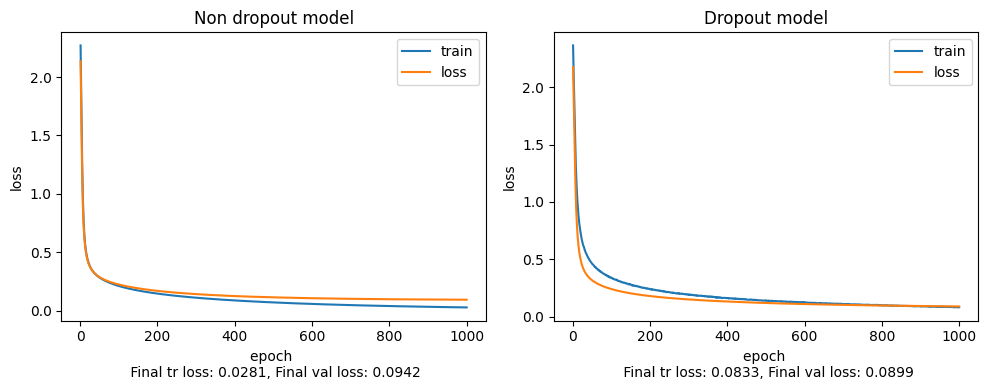

In [5]:
def print_graph(tr_loss, val_loss, tr_loss_dr, val_loss_dr):
    tr_loss = [float(x) for x in tr_loss]
    val_loss = [float(x) for x in val_loss]
    tr_loss_dr = [float(x) for x in tr_loss_dr]
    val_loss_dr = [float(x) for x in val_loss_dr]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i == 0:
            ax.plot(np.arange(1, len(tr_loss)+1), tr_loss, label='train')
            ax.plot(np.arange(1, len(val_loss)+1), val_loss, label='loss')
            ax.set_xlabel(f'epoch \n Final tr loss: {np.round(tr_loss_li[-1], 4)}, Final val loss: {np.round(val_loss_li[-1], 4)}')
            ax.set_ylabel('loss')
            ax.set_title(f'Non dropout model')
            ax.legend()

        if i == 1:
            ax.plot(np.arange(1, len(tr_loss_dr)+1), tr_loss_dr, label='train')
            ax.plot(np.arange(1, len(val_loss_dr)+1), val_loss_dr, label='loss')
            ax.set_xlabel(f'epoch \n Final tr loss: {np.round(tr_loss_li_dr[-1], 4)}, Final val loss: {np.round(val_loss_li_dr[-1], 4)}')
            ax.set_ylabel('loss')
            ax.set_title(f'Dropout model')
            ax.legend()

    plt.tight_layout()
    plt.show()
print_graph(tr_loss_li, val_loss_li, tr_loss_li_dr, val_loss_li_dr)